# Country-Level Analysis of Trending YouTube Videos

### Imports and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

In [2]:
data = "../data/"

df_us = pd.read_csv(data + "USvideos.csv")
df_ca = pd.read_csv(data + "CAvideos.csv")
df_de = pd.read_csv(data + "DEvideos.csv")
df_fr = pd.read_csv(data + "FRvideos.csv")
df_gb = pd.read_csv(data + "GBvideos.csv")
df_in = pd.read_csv(data + "INvideos.csv")
df_jp = pd.read_csv(
    data + "JPvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_kr = pd.read_csv(
    data + "KRvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_mx = pd.read_csv(
    data + "MXvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)
df_ru = pd.read_csv(
    data + "RUvideos.csv",
    encoding="utf-8-sig",
    encoding_errors="replace",
    engine="python"
)

### Pre-processing

In [3]:
df_us["country"] = "US"
df_ca["country"] = "CA"
df_de["country"] = "DE"
df_fr["country"] = "FR"
df_gb["country"] = "GB"
df_in["country"] = "IN"
df_jp["country"] = "JP"
df_kr["country"] = "KR"
df_mx["country"] = "MX"
df_ru["country"] = "RU"

df = pd.concat(
    [df_us, df_ca, df_de, df_fr, df_gb, df_in, df_jp, df_kr, df_mx, df_ru],
    ignore_index=True
)

df.shape

(375942, 17)

In [4]:
df = df.drop_duplicates()

df["description"] = df["description"].fillna("No description")
df["has_description"] = df["description"] != "No description"

df["trending_date"] = df["trending_date"].astype(str).str.strip()
df["trending_date"] = pd.to_datetime(
    df["trending_date"],
    format="%y.%d.%m",
    errors="coerce"
)

df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["publish_time"] = df["publish_time"].dt.tz_localize(None)

df["publish_hour"] = df["publish_time"].dt.hour
df["publish_day"] = df["publish_time"].dt.day_name()
df["days_to_trending"] = (df["trending_date"] - df["publish_time"]).dt.days

df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,country,has_description,publish_hour,publish_day,days_to_trending
0,2kyS6SvSYSE,2017-11-14,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13 17:13:01,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...,US,True,17,Monday,0
1,1ZAPwfrtAFY,2017-11-14,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13 07:30:00,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",US,True,7,Monday,0
2,5qpjK5DgCt4,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12 19:05:24,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...,US,True,19,Sunday,1
3,puqaWrEC7tY,2017-11-14,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13 11:00:04,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...,US,True,11,Monday,0
4,d380meD0W0M,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12 18:01:41,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...,US,True,18,Sunday,1


## 1. Trending Volume per Country

How many trending entries does each country have, and how many unique videos does that represent?

In [5]:
volume = df.groupby("country").agg(
    total_entries=("video_id", "size"),
    unique_videos=("video_id", "nunique")
)
volume["avg_days_on_trending"] = volume["total_entries"] / volume["unique_videos"]
volume = volume.sort_values("unique_videos", ascending=False)
volume

,total_entries,unique_videos,avg_days_on_trending
country,,,
RU,40693,34282,1.187008
MX,40402,33513,1.205562
FR,40724,30581,1.331677
DE,40840,29627,1.378472
CA,40881,24427,1.673599
IN,33089,16307,2.029129
KR,32251,15876,2.031431
JP,14846,12912,1.149783
US,40901,6351,6.440088


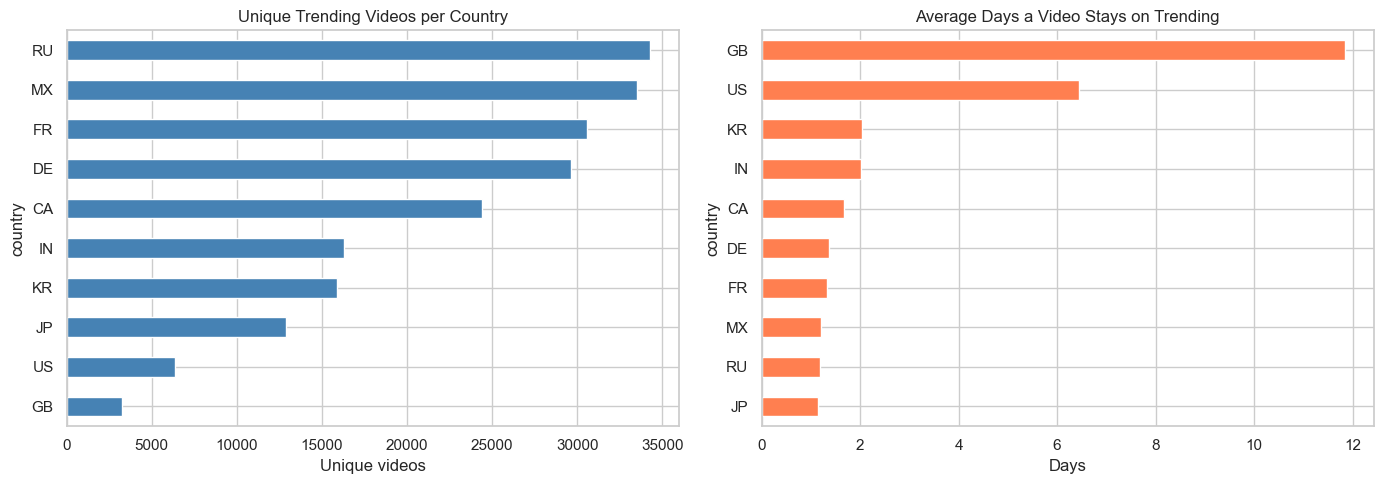

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

volume["unique_videos"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Unique Trending Videos per Country")
axes[0].set_xlabel("Unique videos")

volume["avg_days_on_trending"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("Average Days a Video Stays on Trending")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.savefig("images/country_volume.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Engagement Distributions by Country

Comparing the distributions of views, likes, and comments across countries using violin plots on a log scale to handle the heavy right skew.

/var/folders/80/hqwr4qh5045_gwp_l1039pdw0000gn/T/ipykernel_48318/1610137635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/80/hqwr4qh5045_gwp_l1039pdw0000gn/T/ipykernel_48318/1610137635.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/80/hqwr4qh5045_gwp_l1039pdw0000gn/T/ipykernel_48318/1610137635.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/80/hqwr4qh5045_gwp_l1039pdw0000gn/T/ipykernel_48318/1610137635.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='wid

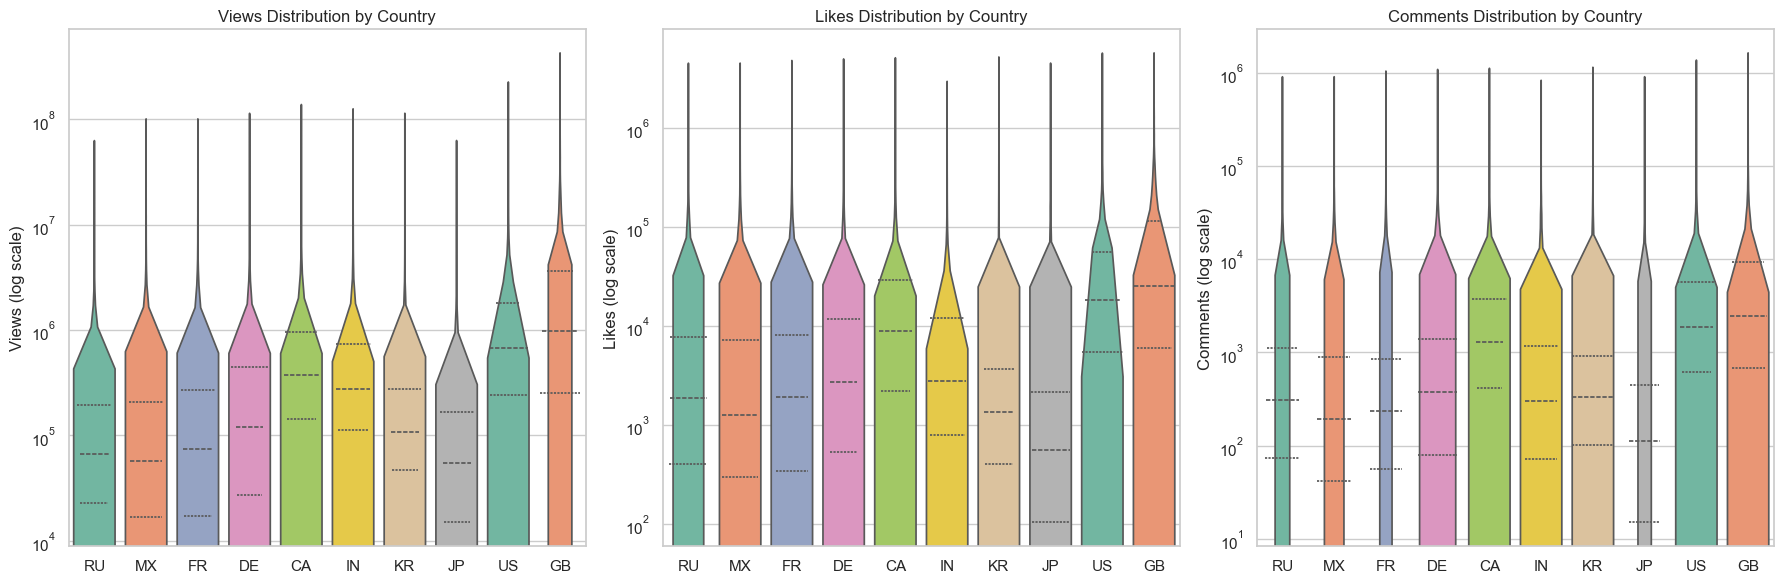

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

country_order = volume.index.tolist()

for ax, col, title in zip(
    axes,
    ["views", "likes", "comment_count"],
    ["Views", "Likes", "Comments"]
):
    sns.violinplot(
        x="country", y=col, data=df, order=country_order,
        scale="width", inner="quartile", ax=ax, palette="Set2"
    )
    ax.set_yscale("log")
    ax.set_title(f"{title} Distribution by Country")
    ax.set_xlabel("")
    ax.set_ylabel(f"{title} (log scale)")

plt.tight_layout()
plt.savefig("images/country_engagement_dist.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
median_stats = df.groupby("country")[["views", "likes", "dislikes", "comment_count"]].median()
median_stats = median_stats.loc[country_order]
median_stats.columns = ["Median Views", "Median Likes", "Median Dislikes", "Median Comments"]
median_stats

,Median Views,Median Likes,Median Dislikes,Median Comments
country,,,,
RU,66201.0,1875.0,128.0,309.0
MX,56793.0,1243.0,63.0,195.0
FR,73721.0,1892.5,83.0,235.0
DE,119277.0,2699.0,134.0,376.0
CA,371204.0,8780.0,303.0,1301.0
IN,275027.0,2757.0,289.0,298.0
KR,108487.0,1345.0,63.0,333.0
JP,54897.0,560.0,35.0,112.0
US,681064.0,18069.0,630.0,1855.0


## 3. Engagement Rates by Country

Raw counts are driven by audience size. Normalizing by views reveals how *engaged* each country's audience actually is — do they like, dislike, or comment more per view?

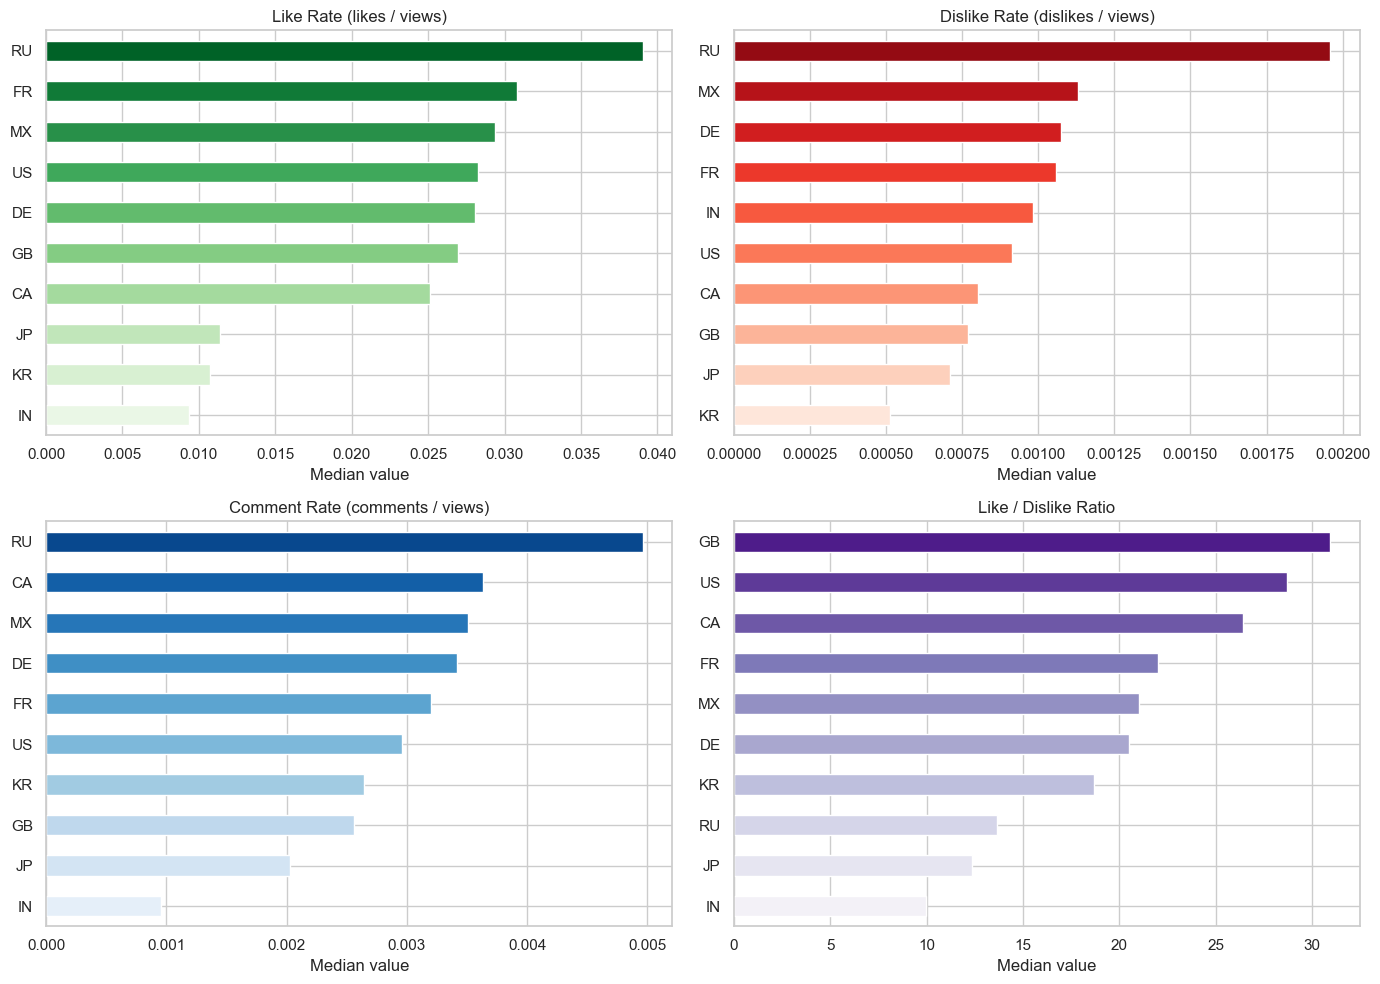

In [9]:
df["like_rate"] = df["likes"] / df["views"]
df["dislike_rate"] = df["dislikes"] / df["views"]
df["comment_rate"] = df["comment_count"] / df["views"]
df["like_dislike_ratio"] = df["likes"] / (df["dislikes"] + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("like_rate", "Like Rate (likes / views)", "Greens"),
    ("dislike_rate", "Dislike Rate (dislikes / views)", "Reds"),
    ("comment_rate", "Comment Rate (comments / views)", "Blues"),
    ("like_dislike_ratio", "Like / Dislike Ratio", "Purples"),
]

for ax, (col, title, cmap) in zip(axes.flat, metrics):
    medians = df.groupby("country")[col].median().sort_values(ascending=True)
    medians.plot.barh(ax=ax, color=sns.color_palette(cmap, len(medians)))
    ax.set_title(title)
    ax.set_xlabel("Median value")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("images/country_engagement_rates.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Category Preferences by Country

What types of content dominate the trending page in each country? We look at the share of each category within each country's trending videos.

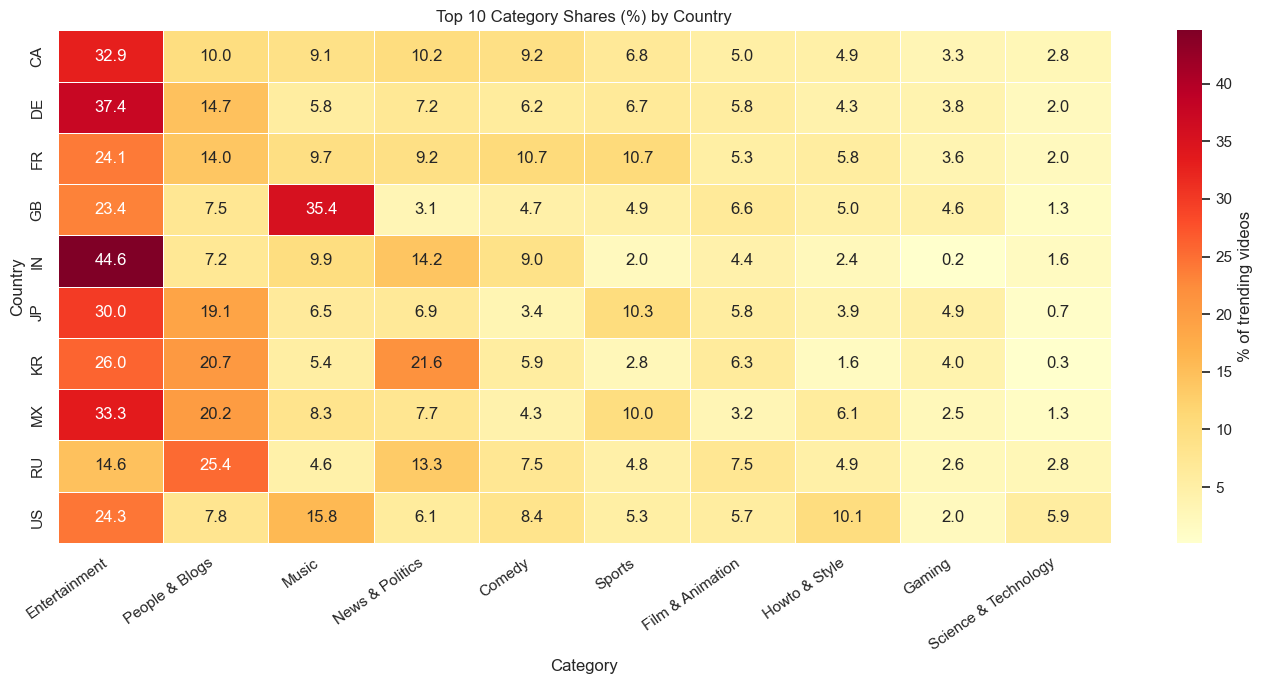

In [10]:
category_map = {
    1: "Film & Animation", 2: "Autos & Vehicles", 10: "Music",
    15: "Pets & Animals", 17: "Sports", 18: "Short Movies",
    19: "Travel & Events", 20: "Gaming", 21: "Videoblogging",
    22: "People & Blogs", 23: "Comedy", 24: "Entertainment",
    25: "News & Politics", 26: "Howto & Style", 27: "Education",
    28: "Science & Technology", 29: "Nonprofits & Activism",
    30: "Movies", 43: "Shows", 44: "Trailers"
}

df["category"] = df["category_id"].map(category_map).fillna("Other")

cat_country = (
    df.groupby(["country", "category"])
    .size()
    .unstack(fill_value=0)
)
cat_country_pct = cat_country.div(cat_country.sum(axis=1), axis=0) * 100

top_cats = cat_country.sum().nlargest(10).index
cat_heatmap = cat_country_pct[top_cats]

plt.figure(figsize=(14, 7))
sns.heatmap(
    cat_heatmap, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, cbar_kws={"label": "% of trending videos"}
)
plt.title("Top 10 Category Shares (%) by Country")
plt.xlabel("Category")
plt.ylabel("Country")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("images/country_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Time to Trending by Country

How quickly do videos reach the trending page after being published? Some countries may favour fresh content while others let videos build momentum over days.

/var/folders/80/hqwr4qh5045_gwp_l1039pdw0000gn/T/ipykernel_48318/220917029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


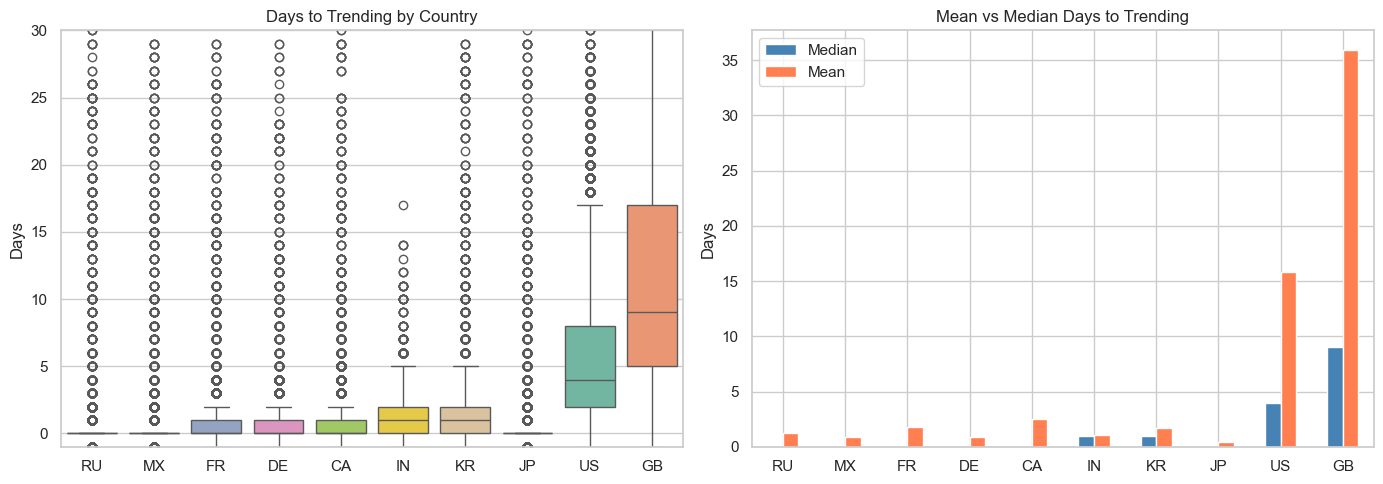

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    x="country", y="days_to_trending", data=df,
    order=country_order, ax=axes[0], palette="Set2"
)
axes[0].set_ylim(-1, 30)
axes[0].set_title("Days to Trending by Country")
axes[0].set_ylabel("Days")
axes[0].set_xlabel("")

trending_speed = df.groupby("country")["days_to_trending"].agg(["median", "mean"])
trending_speed = trending_speed.loc[country_order]
trending_speed.plot.bar(ax=axes[1], color=["steelblue", "coral"])
axes[1].set_title("Mean vs Median Days to Trending")
axes[1].set_ylabel("Days")
axes[1].set_xlabel("")
axes[1].legend(["Median", "Mean"])
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("images/country_time_to_trending.png", dpi=150, bbox_inches="tight")
plt.show()

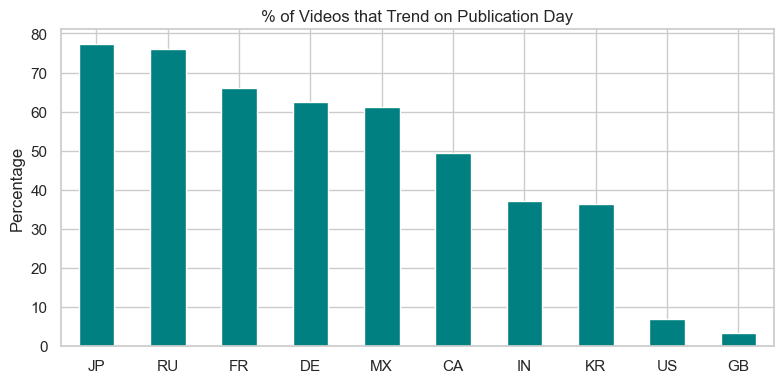

In [12]:
same_day = df[df["days_to_trending"] == 0]
same_day_pct = (
    same_day.groupby("country").size()
    / df.groupby("country").size()
    * 100
).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
same_day_pct.plot.bar(color="teal")
plt.title("% of Videos that Trend on Publication Day")
plt.ylabel("Percentage")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/country_same_day_trending.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Publishing Patterns by Country

When are trending videos published? Differences here reflect both creator habits and timezone effects across countries.

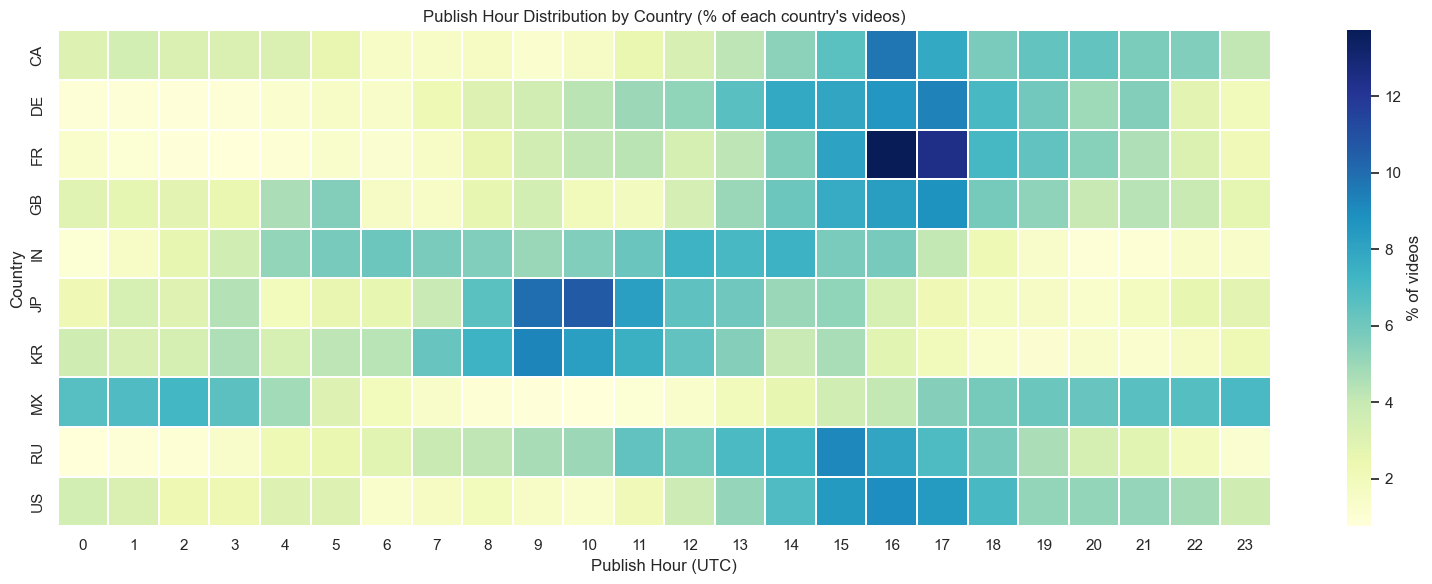

In [13]:
hour_country = (
    df.groupby(["country", "publish_hour"])
    .size()
    .unstack(fill_value=0)
)
hour_country_pct = hour_country.div(hour_country.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 6))
sns.heatmap(
    hour_country_pct, cmap="YlGnBu", annot=False,
    linewidths=0.3, cbar_kws={"label": "% of videos"}
)
plt.title("Publish Hour Distribution by Country (% of each country's videos)")
plt.xlabel("Publish Hour (UTC)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("images/country_publish_hour.png", dpi=150, bbox_inches="tight")
plt.show()

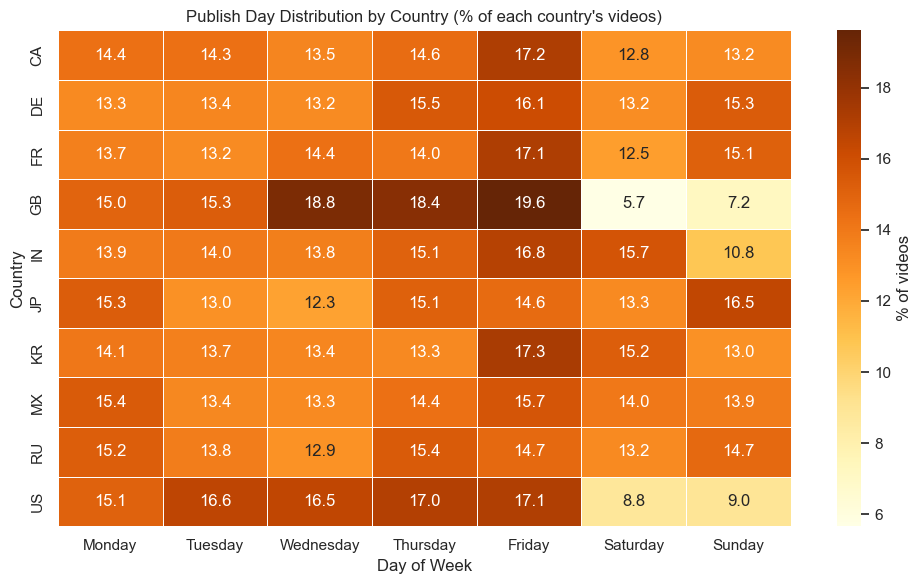

In [14]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_country = (
    df.groupby(["country", "publish_day"])
    .size()
    .unstack(fill_value=0)
)[day_order]
day_country_pct = day_country.div(day_country.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(
    day_country_pct, cmap="YlOrBr", annot=True, fmt=".1f",
    linewidths=0.5, cbar_kws={"label": "% of videos"}
)
plt.title("Publish Day Distribution by Country (% of each country's videos)")
plt.xlabel("Day of Week")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("images/country_publish_day.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cross-Country Video Overlap

Do the same videos trend in multiple countries, or does each country have its own distinct trending ecosystem? We measure overlap using Jaccard similarity between each pair of countries' video sets.

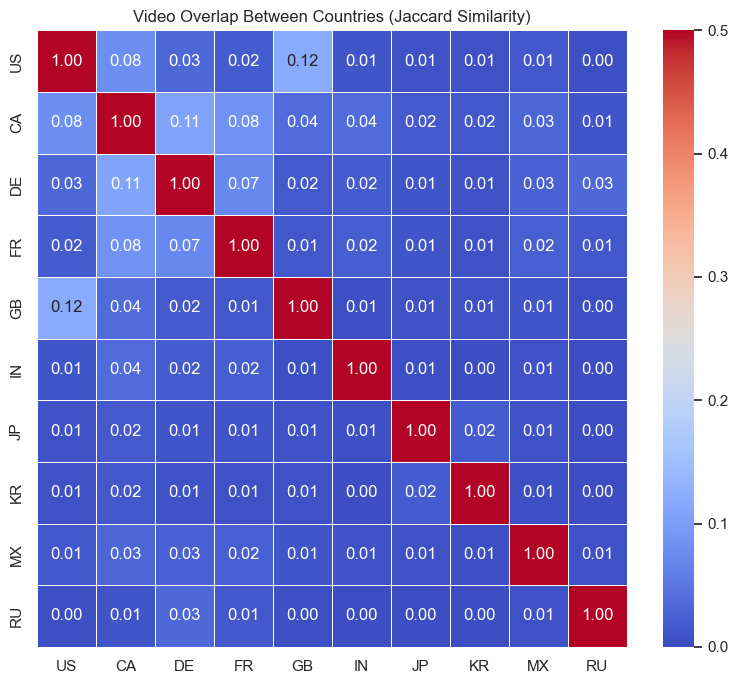

In [15]:
countries = df["country"].unique()
video_sets = {c: set(df.loc[df["country"] == c, "video_id"]) for c in countries}

jaccard = pd.DataFrame(index=countries, columns=countries, dtype=float)
for c1 in countries:
    for c2 in countries:
        inter = len(video_sets[c1] & video_sets[c2])
        union = len(video_sets[c1] | video_sets[c2])
        jaccard.loc[c1, c2] = inter / union if union > 0 else 0

plt.figure(figsize=(8, 7))
sns.heatmap(
    jaccard.astype(float), annot=True, fmt=".2f",
    cmap="coolwarm", vmin=0, vmax=0.5, linewidths=0.5
)
plt.title("Video Overlap Between Countries (Jaccard Similarity)")
plt.tight_layout()
plt.savefig("images/country_overlap_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()

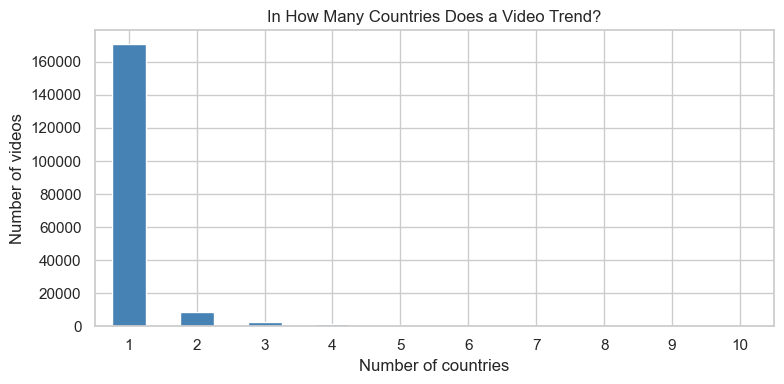

Videos trending in only 1 country: 170518 (92.5%)
Videos trending in 5+ countries:   1014 (0.6%)


In [16]:
n_countries_per_video = df.groupby("video_id")["country"].nunique()

plt.figure(figsize=(8, 4))
n_countries_per_video.value_counts().sort_index().plot.bar(color="steelblue")
plt.title("In How Many Countries Does a Video Trend?")
plt.xlabel("Number of countries")
plt.ylabel("Number of videos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("images/country_multi_trending.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Videos trending in only 1 country: {(n_countries_per_video == 1).sum()} "
      f"({(n_countries_per_video == 1).mean() * 100:.1f}%)")
print(f"Videos trending in 5+ countries:   {(n_countries_per_video >= 5).sum()} "
      f"({(n_countries_per_video >= 5).mean() * 100:.1f}%)")

Which categories tend to cross borders the most?

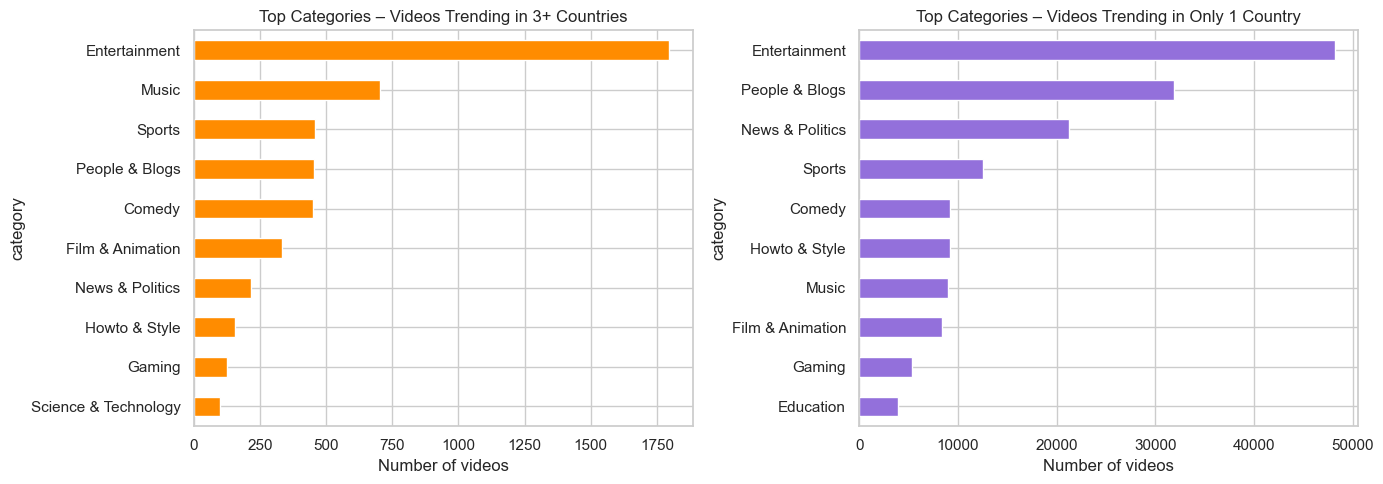

In [17]:
video_meta = df.drop_duplicates("video_id")[["video_id", "category"]].copy()
video_meta["n_countries"] = video_meta["video_id"].map(n_countries_per_video)

global_videos = video_meta[video_meta["n_countries"] >= 3]
local_videos = video_meta[video_meta["n_countries"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

global_videos["category"].value_counts().head(10).plot.barh(ax=axes[0], color="darkorange")
axes[0].set_title("Top Categories – Videos Trending in 3+ Countries")
axes[0].invert_yaxis()
axes[0].set_xlabel("Number of videos")

local_videos["category"].value_counts().head(10).plot.barh(ax=axes[1], color="mediumpurple")
axes[1].set_title("Top Categories – Videos Trending in Only 1 Country")
axes[1].invert_yaxis()
axes[1].set_xlabel("Number of videos")

plt.tight_layout()
plt.savefig("images/country_global_vs_local_categories.png", dpi=150, bbox_inches="tight")
plt.show()

---

# Temporal Evolution of Trends by Country

The previous sections compared countries in aggregate. Now we ask: **how do these patterns change over time?** We derive a `trending_month` column to group the data into monthly windows and track the evolution of each metric.

In [18]:
df["trending_month"] = df["trending_date"].dt.to_period("M")

print("Time range:", df["trending_month"].min(), "→", df["trending_month"].max())
print("Number of months:", df["trending_month"].nunique())

Time range: 2017-11 → 2018-06
Number of months: 8


## 8. Trending Volume Over Time by Country

Do all countries have the same data-collection window? Does the number of trending entries grow, shrink, or stay flat over time?

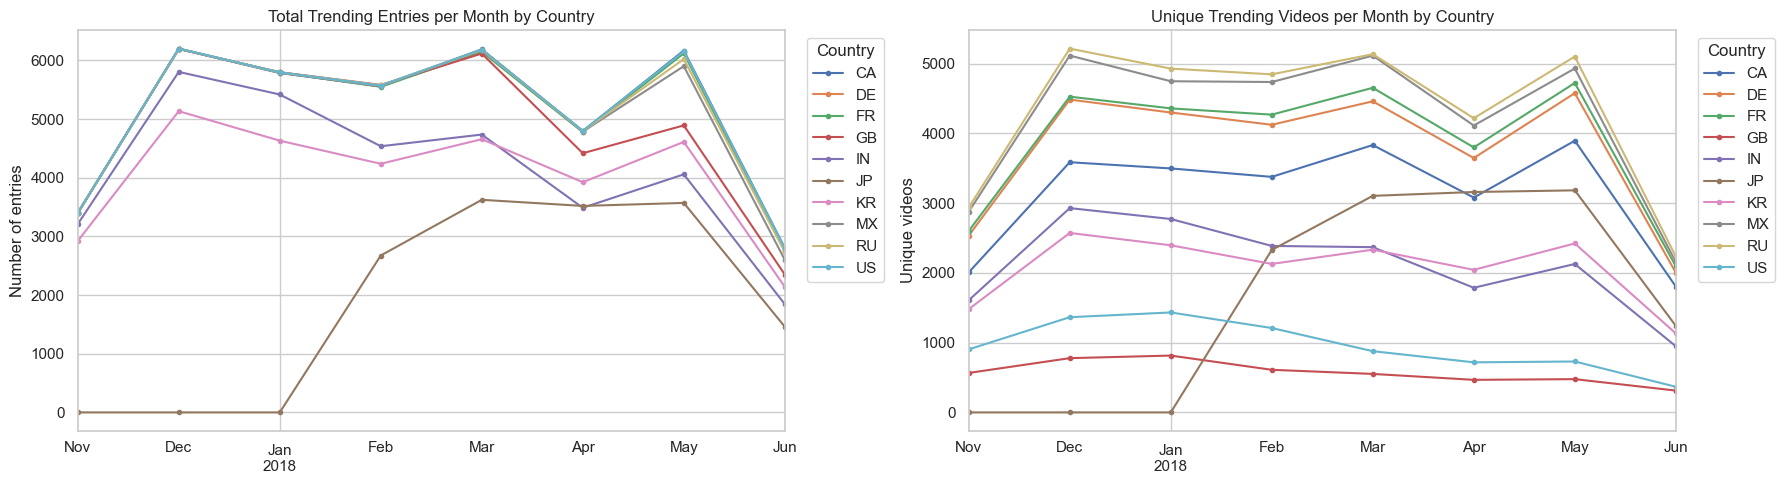

In [19]:
monthly_volume = (
    df.groupby(["trending_month", "country"])
    .size()
    .unstack(fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

monthly_volume.plot(ax=axes[0], marker="o", markersize=3)
axes[0].set_title("Total Trending Entries per Month by Country")
axes[0].set_ylabel("Number of entries")
axes[0].set_xlabel("")
axes[0].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

monthly_unique = (
    df.groupby(["trending_month", "country"])["video_id"]
    .nunique()
    .unstack(fill_value=0)
)
monthly_unique.plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("Unique Trending Videos per Month by Country")
axes[1].set_ylabel("Unique videos")
axes[1].set_xlabel("")
axes[1].legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("images/country_volume_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Engagement Evolution Over Time by Country

How do median views, likes, and comment counts on trending videos change month-over-month in each country?

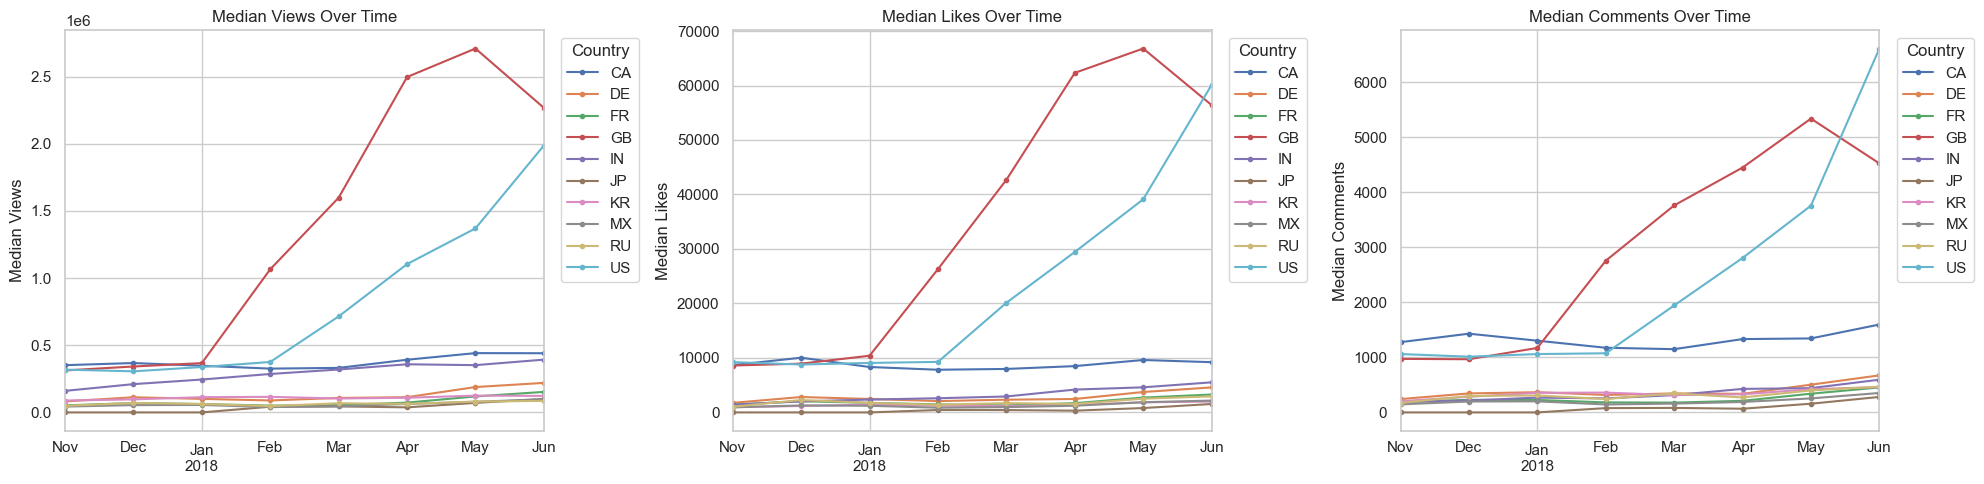

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["views", "likes", "comment_count"],
    ["Median Views", "Median Likes", "Median Comments"]
):
    pivot = (
        df.groupby(["trending_month", "country"])[col]
        .median()
        .unstack(fill_value=0)
    )
    pivot.plot(ax=ax, marker="o", markersize=3)
    ax.set_title(f"{title} Over Time")
    ax.set_ylabel(title)
    ax.set_xlabel("")
    ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("images/country_engagement_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

We can also look at the evolution of *engagement rates* (normalized by views) over time to see if audience behaviour changes.

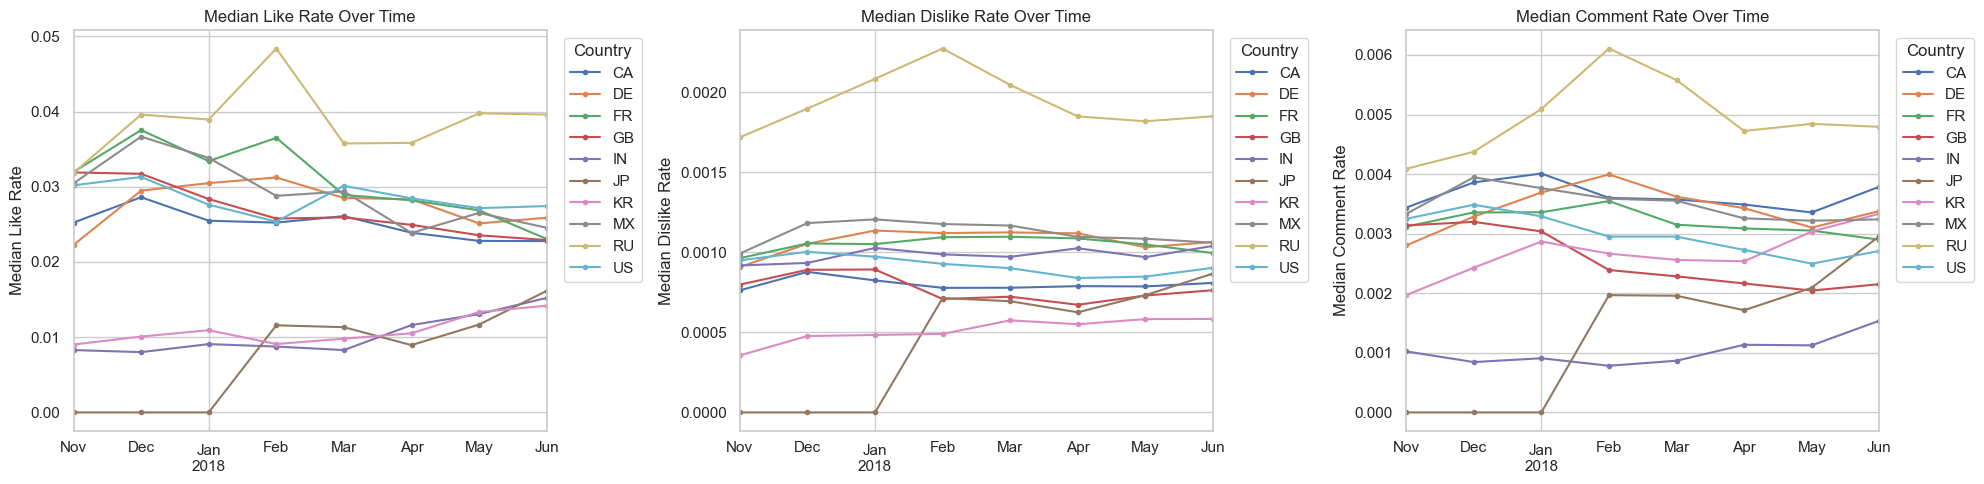

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, col, title in zip(
    axes,
    ["like_rate", "dislike_rate", "comment_rate"],
    ["Median Like Rate", "Median Dislike Rate", "Median Comment Rate"]
):
    pivot = (
        df.groupby(["trending_month", "country"])[col]
        .median()
        .unstack(fill_value=0)
    )
    pivot.plot(ax=ax, marker="o", markersize=3)
    ax.set_title(f"{title} Over Time")
    ax.set_ylabel(title)
    ax.set_xlabel("")
    ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig("images/country_engagement_rates_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Category Popularity Shifts Over Time

Does the trending page composition change over time? We pick two contrasting countries and show how the share of the top categories evolves month by month.

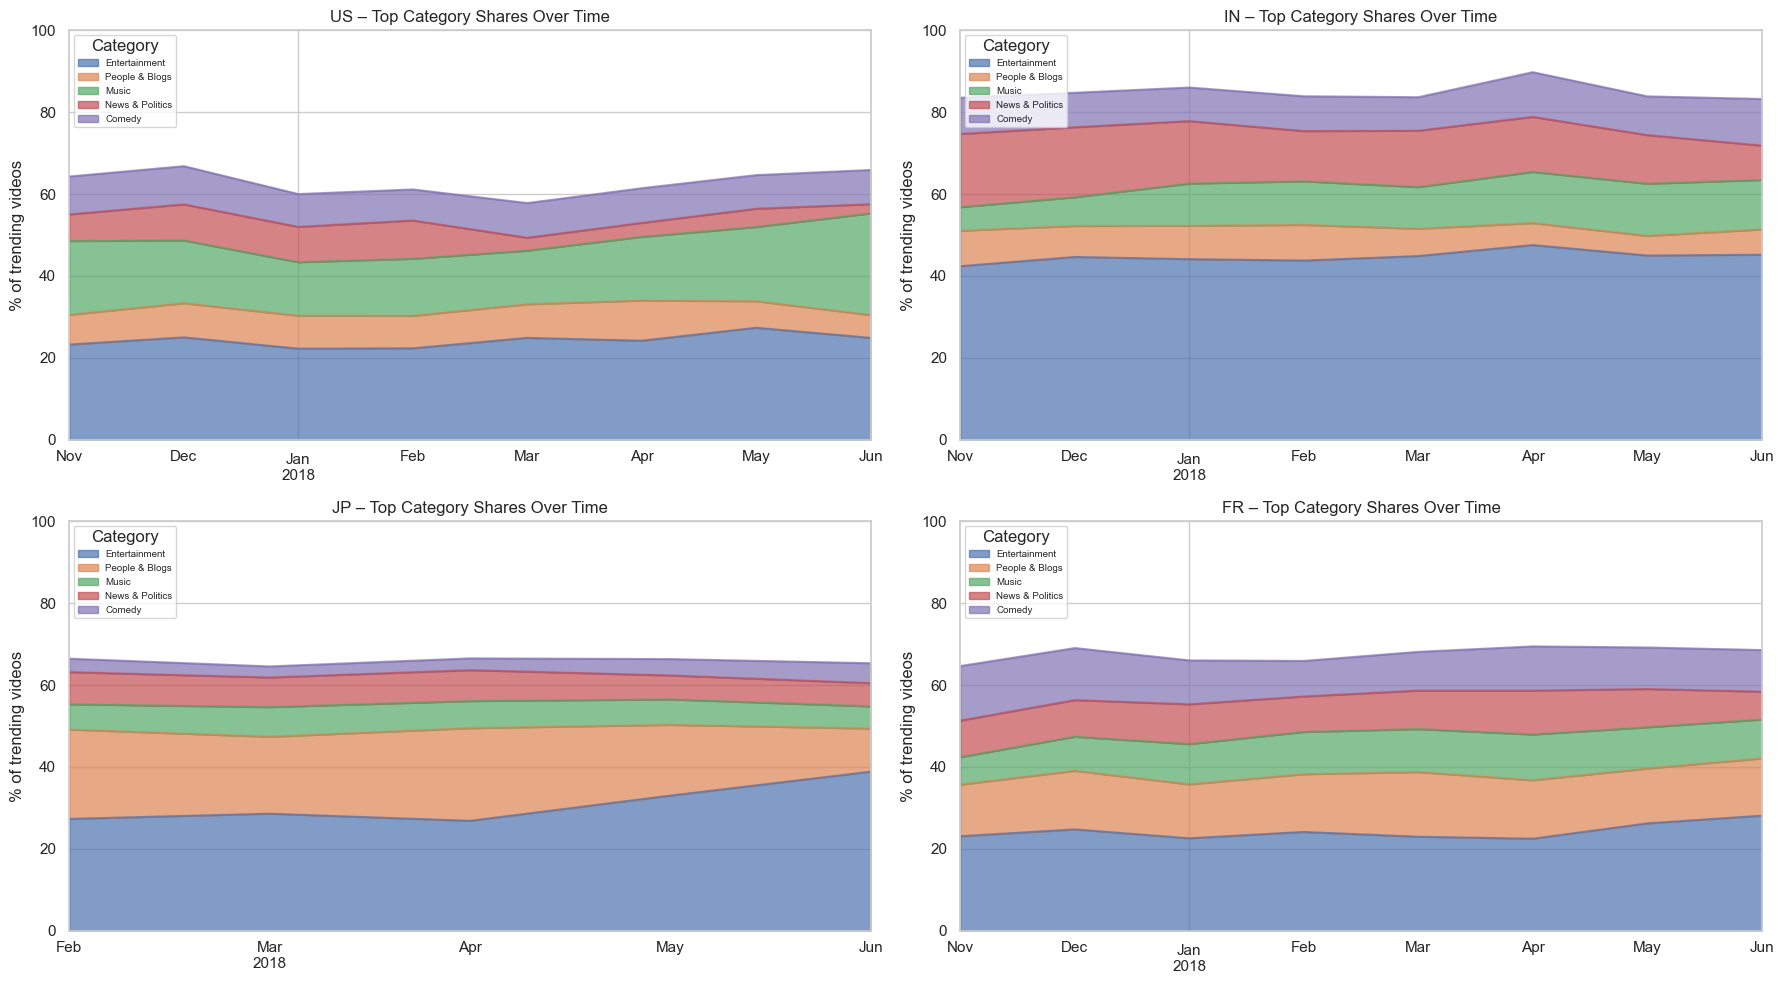

In [22]:
top_5_cats = df["category"].value_counts().head(5).index.tolist()

focus_countries = ["US", "IN", "JP", "FR"]
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for ax, country in zip(axes.flat, focus_countries):
    sub = df[df["country"] == country]
    cat_time = (
        sub.groupby(["trending_month", "category"])
        .size()
        .unstack(fill_value=0)
    )
    cat_time_pct = cat_time.div(cat_time.sum(axis=1), axis=0) * 100

    cols_to_plot = [c for c in top_5_cats if c in cat_time_pct.columns]
    cat_time_pct[cols_to_plot].plot.area(ax=ax, alpha=0.7, stacked=True)
    ax.set_title(f"{country} – Top Category Shares Over Time")
    ax.set_ylabel("% of trending videos")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
    ax.legend(title="Category", fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("images/country_category_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Time-to-Trending Speed Over Time

Are videos reaching the trending page faster or slower as time goes on? We track the median `days_to_trending` per month for each country.

<Figure size 1400x500 with 0 Axes>

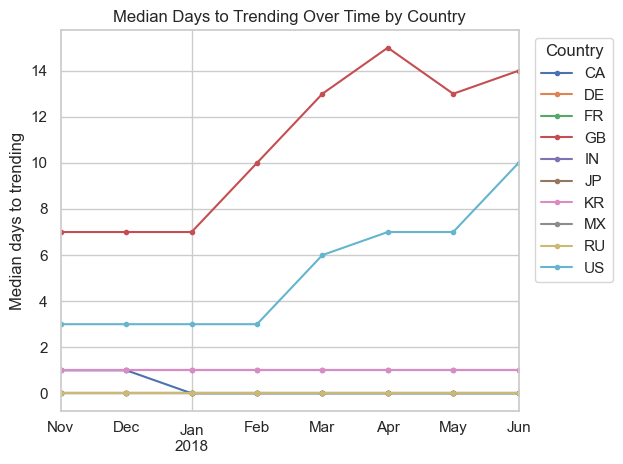

In [23]:
speed_over_time = (
    df.groupby(["trending_month", "country"])["days_to_trending"]
    .median()
    .unstack(fill_value=0)
)

plt.figure(figsize=(14, 5))
speed_over_time.plot(marker="o", markersize=3)
plt.title("Median Days to Trending Over Time by Country")
plt.ylabel("Median days to trending")
plt.xlabel("")
plt.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("images/country_speed_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Cross-Country Overlap Over Time

Do countries converge toward the same viral content as time goes on, or does each country become more "local"? For each month we compute the fraction of videos that trend in **more than one country**.

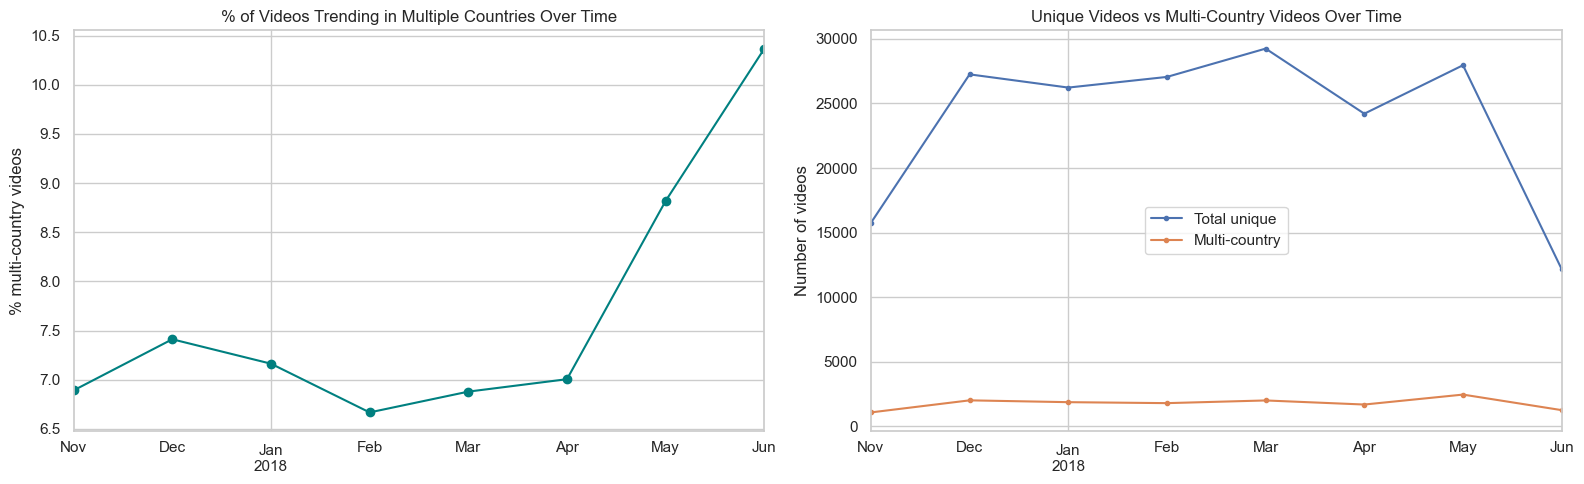

In [24]:
monthly_overlap = []

for month, group in df.groupby("trending_month"):
    vids_per_country = group.groupby("video_id")["country"].nunique()
    total_unique = len(vids_per_country)
    multi_country = (vids_per_country > 1).sum()
    monthly_overlap.append({
        "month": month,
        "total_unique_videos": total_unique,
        "multi_country_videos": multi_country,
        "multi_country_pct": multi_country / total_unique * 100 if total_unique else 0
    })

df_overlap = pd.DataFrame(monthly_overlap).set_index("month")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_overlap["multi_country_pct"].plot(ax=axes[0], marker="o", color="teal")
axes[0].set_title("% of Videos Trending in Multiple Countries Over Time")
axes[0].set_ylabel("% multi-country videos")
axes[0].set_xlabel("")

df_overlap[["total_unique_videos", "multi_country_videos"]].plot(ax=axes[1], marker="o", markersize=3)
axes[1].set_title("Unique Videos vs Multi-Country Videos Over Time")
axes[1].set_ylabel("Number of videos")
axes[1].set_xlabel("")
axes[1].legend(["Total unique", "Multi-country"])

plt.tight_layout()
plt.savefig("images/country_overlap_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

We can also track the Jaccard similarity between selected country pairs month-over-month to see if specific pairs converge or diverge.

<Figure size 1400x500 with 0 Axes>

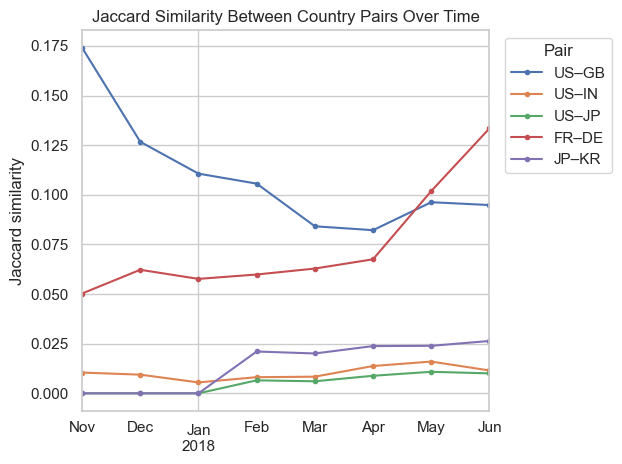

In [25]:
pairs = [("US", "GB"), ("US", "IN"), ("US", "JP"), ("FR", "DE"), ("JP", "KR")]

pair_jaccard_over_time = {f"{a}–{b}": [] for a, b in pairs}
months = sorted(df["trending_month"].dropna().unique())

for month in months:
    group = df[df["trending_month"] == month]
    sets_by_country = {c: set(g["video_id"]) for c, g in group.groupby("country")}
    for a, b in pairs:
        sa = sets_by_country.get(a, set())
        sb = sets_by_country.get(b, set())
        union = len(sa | sb)
        j = len(sa & sb) / union if union > 0 else 0
        pair_jaccard_over_time[f"{a}–{b}"].append(j)

df_pair_jaccard = pd.DataFrame(pair_jaccard_over_time, index=months)

plt.figure(figsize=(14, 5))
df_pair_jaccard.plot(marker="o", markersize=3)
plt.title("Jaccard Similarity Between Country Pairs Over Time")
plt.ylabel("Jaccard similarity")
plt.xlabel("")
plt.legend(title="Pair", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("images/country_pair_jaccard_over_time.png", dpi=150, bbox_inches="tight")
plt.show()